# What is done here ?
>**Processing**
*| "Variance is what we need" |*
* **Brains Refereshment on a larger scale??**
    * If everyone who part-taked in this survey was `not edligible` , could there be any informative detail about edligibility that could be extracted ?? No, This is the Reason why a group with constant edligibility has no information on its own.
    * If we had just one person who partaked in this survay, could it be informative ? No , but if we add other unique individuals to the survay , this creates some variance which helps produce information hence the reason behind the grouping of groups with only one participant into a more general group called `autre`.
    * If only `males` took part in this survay, could there be need to consider gender?? No, which is while atributes with no variance where removed.
    * Most of all, if an atribute has no significant relation with the main goal ( `edligibility` ), then it will be removed. This will be done using stastitical methods and then validated using `general knowledge`

* **Applying on a smaller scale** :
    * If every field under a group has a constant edligibility i.e the variance of edligibility in the group is 0, then the group is discarded and its fields merged with another group called `autre`. Groups where edligibility is constant has no informative insights to give concerning edligibility, But on grouping these groups into a seperate group creates some variance which is good for `ML` nodels.
    * Atributes like profession , place of residence and .... have a lot of inconsistencies( 70%  spelling error ) , So to mitigate this, fields under this atributes will be futher grouped into more broader groups. If any of the broader groups has only one field then the group will be merdged into another group called `autre` < This will reduce the presence of outliers and hence lead to stable clustering. 
    * Any atribute with no variance was removed from the clustering list
    * Methods for measuring correlation and f-statitics will be used to ensure there is a significant relationship between an atribute and the main goal before using it for clustering
    
>**Clustering**
  * Ounce the data is processed and the neccesary columns validated for clustering sited out, then we cluster.
  * The `Ideal donor group` is the group (or cluster) with most edligible donors

>**Insights**
  * The charecteristics of the donors in the ideal group is then studied for which follows a `detailed` easy to understand note of the results


# Imports

In [114]:

from sklearn.preprocessing import OneHotEncoder , LabelEncoder
import pandas as pd , joblib
import numpy as np , re
import matplotlib.pyplot as plt , seaborn as sns
import dython
from dython.nominal import associations, cramers_v, theils_u
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import plotly.express as px
from scipy.stats import f_oneway
# @title
from scipy import stats
from colorama import Fore as F

---
**Loading data**

In [120]:
import os

current_dir = os.getcwd()

parent_dir = os.path.abspath(os.path.join(current_dir, '..'))

#Excel sheet path
data_dir = os.path.join(parent_dir, 'data', 'processed')
path = os.path.join(data_dir, 'processed.xlsx')
try:
    df = pd.read_excel(path)
    display(df.head())
except FileNotFoundError:
    print(f"Error: {path} not found.")
    df = None
except Exception as e:
    print(f"An error occurred: {e}")
    df = None

,Date de remplissage de la fiche,Date de naissance,Niveau d'etude,Genre,Taille,Poids,Situation Matrimoniale (SM),Profession,Arrondissement de résidence,Quartier de Résidence,...,"Raison de non-eligibilité totale [Porteur(HIV,hbs,hcv)]",Raison de non-eligibilité totale [Opéré],Raison de non-eligibilité totale [Drepanocytaire],Raison de non-eligibilité totale [Diabétique],Raison de non-eligibilité totale [Hypertendus],Raison de non-eligibilité totale [Asthmatiques],Raison de non-eligibilité totale [Cardiaque],Raison de non-eligibilité totale [Tatoué],Raison de non-eligibilité totale [Scarifié],Si autres raison préciser
0,3/11/0019,1999-09-01 00:00:00,Pas Précisé,Homme,NaN,NaN,Célibataire,Chaudronnier,Douala 3,Logbaba,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3/21/0019,1978-02-04 00:00:00,Universitaire,Homme,NaN,NaN,Marié (e),Secrétaire comptable,Douala (Non précisé ),NDOGPASSI 2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1977-12-25 00:00:00,1977-12-25 00:00:00,Secondaire,Femme,NaN,NaN,Marié (e),Commerçant (e),Douala (Non précisé ),Dakar,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1986-02-06 00:00:00,1986-02-06 00:00:00,Secondaire,Homme,NaN,NaN,Célibataire,Homme d’affaire,Douala 5,NGANGUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1988-05-20 00:00:00,1988-05-20 00:00:00,Pas Précisé,Homme,NaN,NaN,Célibataire,Beat Maker,Douala (Non précisé ),Douala,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# All functions and Sheets template

In [ ]:
# @title
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from scipy.stats import chi2_contingency

def one_hot_encode_column(column, drop_first=True, use_sklearn=False):
    """
    One-hot encode a single column from a dataset.
    """
    if isinstance(column, np.ndarray):
        column = pd.Series(column)

    if not use_sklearn:
        encoded = pd.get_dummies(column, drop_first=drop_first, dtype=int)
        return np.array(encoded)
    else:
        encoder = OneHotEncoder(drop='first' if drop_first else None, sparse_output=False)
        encoded = encoder.fit_transform(column.values.reshape(-1, 1))
        encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out([column.name]))
        return encoded_df


def cramers_v(x, y):
    """
    Calculate Cramér's V for two categorical variables.

    """

    x = np.array(x)
    y = np.array(y)

    # contingency table
    contingency_table = pd.crosstab(x, y)

    chi2 = chi2_contingency(contingency_table)[0]

    n = contingency_table.sum().sum()
    phi2 = chi2 / n
    r, k = contingency_table.shape
    phi2corr = max(0, phi2)
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    if min((kcorr - 1), (rcorr - 1)) < 0:
        raise ValueError("Cramér's V is not defined for this contingency table.")

    cramers_v = np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

    return cramers_v

#Function to rename columns
def apply_renaming(df , rename_functions):
    for func in rename_functions:
        df = df.rename(columns=func)
    return df

# Function to calculate variance for all columns, handling numeric and non-numeric
def calculate_variance(sheet):
    variance_dict = {}
    le = LabelEncoder()

    for col in sheet.columns:
        if pd.api.types.is_numeric_dtype(sheet[col]):
            variance_dict[col] = sheet[col].var()
        else:
            sheet[col] = le.fit_transform(sheet[col].astype(str))
            variance_dict[col] = sheet[col].var()
    return variance_dict

def replace_with_autre_preprocessor(sheet, sited_groups):
    def processor(x):
        for col_name, records in sited_groups.items():
            if sheet.column_name == col_name and x in records:
                return 'autre'
        return x

    return lambda sheet: sheet.preprocess_columns(process_function=processor)


def visualize_attribute_impact(sheet, target_column, attribute_columns, color_map={1: 'orange', 0: 'blue'}, bins=10):
    """
    Visualizes the impact of attributes on the target variable (eligibility status).

    """
    
    for column in attribute_columns:
        plt.figure(figsize=(15, 10))
        
        # Determine column type and prepare data
        if pd.api.types.is_numeric_dtype(sheet.sheet[column]):
            # Bin numeric columns into ranges
            sheet.sheet[f'{column}_range'] = pd.cut(sheet.sheet[column], bins=bins)
            plot_column = f'{column}_range'
        else:
            plot_column = column
            
        # Group data and get total counts
        grouped = sheet.sheet.groupby([plot_column, target_column])[target_column].count().unstack()
        total_counts = grouped.sum(axis=1)

        # Create plot
        ax = grouped.plot(kind='bar', color=[color_map[0], color_map[1]])

        # Add total count lines
        for i, count in enumerate(total_counts):
            ax.plot([i - 0.25, i + 0.25], [count, count], 
                   color='black', linestyle='--', linewidth=2)
            ax.text(i, count + 5, str(count), ha='center', va='bottom', fontsize=10)

        # Formatting
        plt.title(f'Impact of {column} on Eligibility Status')
        plt.xlabel(plot_column)
        plt.ylabel('Count')
        plt.legend(title='Eligibility Status')

        plt.show()







---
Relationship Evaluation Functions



In [ ]:
# @title
def calculate_dependence_on_target(self, target_column, other_columns, test_type='anova', show_plot=False, alpha=0.05):
    """
    Calculate dependence of other columns on a target numeric column, with multiple comparison correction and effect size.
    Returns a list of columns considered not significantly dependent (excluded).

    """
    if target_column not in self.sheet.columns:
        raise ValueError(f"Target column '{target_column}' does not exist in the sheet.")

    if test_type not in ['anova', 'kruskal']:
        raise ValueError(f"Invalid test_type. Choose 'anova' or 'kruskal'.")

    # Split columns into numeric and categorical
    numeric_cols = []
    categorical_cols = []

    for col in other_columns:
        if col not in self.sheet.columns:
            raise ValueError(f"Column '{col}' does not exist in the sheet.")
        if pd.api.types.is_numeric_dtype(self.sheet[col]):
            numeric_cols.append(col)
        else:
            categorical_cols.append(col)

    # Calculate dependence for numeric columns using Pearson correlation
    numeric_dependence = []
    for col in numeric_cols:
        corr = self.sheet[target_column].corr(self.sheet[col], method='pearson')
        numeric_dependence.append({'Column': col, 'Correlation': corr})

        if show_plot:
            plt.figure(figsize=(8, 5))
            plt.scatter(self.sheet[col], self.sheet[target_column], alpha=0.7)
            plt.title(f"{col} vs {target_column} (Correlation: {corr:.2f})")
            plt.xlabel(col)
            plt.ylabel(target_column)
            plt.show()

    numeric_dependence_df = pd.DataFrame(numeric_dependence)

    # Calculate dependence for categorical columns using ANOVA or Kruskal-Wallis
    categorical_dependence = []
    num_categorical_tests = len(categorical_cols)
    excluded_columns = []

    for col in categorical_cols:
        groups = self.sheet.groupby(col)[target_column].apply(list)

        if len(groups) >= 2:
            try:
                if test_type == 'anova':
                    f_stat, p_value = stats.f_oneway(*groups)
                    test_name = 'ANOVA F-statistic'
                    stat_value = f_stat
                    # Calculate Eta-squared effect size
                    n_total = len(self.sheet[target_column])
                    ss_between = (f_stat * (len(groups) - 1) * np.var(self.sheet[target_column])) # Approximation of SS_between from F-statistic
                    eta_squared = ss_between / np.sum((self.sheet[target_column] - np.mean(self.sheet[target_column]))**2) if np.sum((self.sheet[target_column] - np.mean(self.sheet[target_column]))**2) > 0 else 0 # Avoid division by zero
                    effect_size = eta_squared
                    effect_size_name = 'Eta-squared'


                elif test_type == 'kruskal':
                    h_stat, p_value = stats.kruskal(*groups)
                    test_name = 'Kruskal-Wallis H-statistic'
                    stat_value = h_stat
                    # Calculate Epsilon-squared effect size
                    n_total = len(self.sheet[target_column])
                    k = len(groups)
                    epsilon_squared = (h_stat - (k - 1)) / (n_total - 1) if (n_total - 1) > 0 else 0 # Avoid division by zero
                    effect_size = epsilon_squared
                    effect_size_name = 'Epsilon-squared'


                bonferroni_p_value = min(p_value * num_categorical_tests, 1.0) # Bonferroni correction, cap at 1
                categorical_dependence.append({
                    'Column': col,
                    test_name: stat_value,
                    'P-value': p_value,
                    'Bonferroni P-value': bonferroni_p_value,
                    'Test Used': test_type.upper(),
                    effect_size_name: effect_size
                })

                if bonferroni_p_value > alpha: # Check for exclusion based on Bonferroni p-value
                    excluded_columns.append(col)


                if show_plot:
                    means = [np.mean(g) for g in groups]
                    plt.figure(figsize=(8, 5))
                    plt.bar(groups.index.astype(str), means)
                    plt.title(f"{col} vs {target_column} ({test_type.upper()} P-value: {p_value:.2e}, Bonferroni P: {bonferroni_p_value:.2e})")
                    plt.xlabel(col)
                    plt.ylabel(f"Mean of {target_column}")
                    plt.show()

            except ValueError as e:
                print(f"Warning: {test_type.upper()} failed for column '{col}'. Reason: {e}")
                categorical_dependence.append({
                    'Column': col,
                    'F-statistic': None, # Still using F-statistic column name for consistency in case of ANOVA
                    'P-value': None,
                    'Bonferroni P-value': None,
                    'Test Used': test_type.upper(),
                    'Effect Size': None # Generic effect size name in error case
                })
                excluded_columns.append(col) # Treat as excluded if test fails

        else:  # Handle cases with insufficient groups
            categorical_dependence.append({
                'Column': col,
                'F-statistic': None, # Still using F-statistic column name for consistency in case of ANOVA
                'P-value': None,
                'Bonferroni P-value': None,
                'Test Used': test_type.upper(),
                'Effect Size': None # Generic effect size name in insufficient groups case
            })
            excluded_columns.append(col)


    categorical_dependence_df = pd.DataFrame(categorical_dependence)

    return numeric_dependence_df, categorical_dependence_df, excluded_columns

#creating subsets of data after clustering
def get_cluster_subset(self , cluster_label):
    """
    Creates a subset of the dataset for a specific cluster group.

    """
    cluster_data = self.sheet[self.sheet['cluster'] == cluster_label]
    # new Sheet object with the subset data
    new_sheet = Sheet(name=None)
    new_sheet.sheet = cluster_data
    return new_sheet




---

Sheet class . This is a template to better manage sheets in the dataset

In [6]:
# @title

class Sheet ( ):
  def __init__(self , name, new_column_names = {}):
    if not name : return
    self.name = name
    self.pre_processing_functions = [ ]
    self.sheet = pd.read_excel(path, sheet_name=name)
    self.old_column_names = self.sheet.columns.tolist()
    self.lang = 'fr'
    if new_column_names:
      self.rename_columns(new_column_names)
  def toggle_names ( self ):
    temp = self.old_column_names
    if self.lang == 'fr':
      self.lang = 'en'
    else :
      self.lang = 'fr'
    self.old_column_names = self.sheet.columns.tolist()
    self.rename_columns(temp , lang = self.lang )
  def get_column ( self , column_name):
    return self.sheet[column_name].values
  def add_pre_processing_function(self, function):
    if type ( function) == list :
      self.pre_processing_functions += function
    else :
      self.pre_processing_functions.append(function)
  def apply_pre_processing_functions(self , clear_on_applied = True):
    for function in self.pre_processing_functions:
      function(self)
    if clear_on_applied :
      self.pre_processing_functions = [ ]
  def preprocess_column(self , column_name = None , process_function = lambda text: text , excludes = [] ):
    if column_name is None :
      for column_name in self.sheet.columns:
        if column_name not in excludes : self.sheet[column_name] = self.sheet[column_name].apply(process_function)
    else :self.sheet[column_name] = self.sheet[column_name].apply(process_function)
    return self.get_columns()
  def preprocess_columns ( self , columns = [] , excludes = [] , process_function = lambda text : text ):
    if not columns : columns = self.get_columns()
    for column_name in columns:
      self.column_name = column_name
      if column_name not in excludes : self.sheet[column_name] = self.sheet[column_name].apply(process_function)
    self.column_name = None
  def get_most_frequent(self , column_name):
    return self.sheet[column_name].value_counts().idxmax( )
  def count_nulls(self , column_name):
    return self.sheet[column_name].isnull().sum()
  def count_value ( self , column_name , value = '' ):
    return (self.sheet[column_name] == value).sum()
  def get_records_in_column(self , column_name):
    records = [ ]
    for record in self.sheet[column_name]:
      records.append(record)
    return records
  def get_column_details (self ,  column_name , show_contents = True):
    """Displays the unique values and their frequencies in the specified column."""

    value_counts = self.sheet[column_name].value_counts()
    print(f"nulls count : {self.count_nulls(column_name)}")
    print(f"Unique values in column '{column_name}':")
    print(value_counts)

  def display_fields(self):
    for column_name in self.sheet.columns:
      print(f'\n\n_______ {column_name.title()} ______\n')
      self.get_column_details(column_name)

  #COLUMN RENAMING

  def get_columns(self):
    columns = self.sheet.columns.tolist()
    if 'cluster' in columns : columns.remove('cluster')
    return columns

  def rename_columns ( self , new_column_names , lang = 'en' ):
    self.lang = lang
    self.old_column_names = self.sheet.columns.tolist()
    if type ( new_column_names) == list :
      new_column_names = {self.sheet.columns[i]:new_column_names[i] for i in range(len(new_column_names))}
    self.sheet.rename(columns=new_column_names, inplace=True)

  def translate_columns(self , preprocess = lambda text: text , lang = 'en' ):
    self.lang = lang
    self.old_column_names = self.sheet.columns.tolist()
    for col in self.sheet.columns:
      self.sheet.rename(columns={col:preprocess(translate(col))}, inplace=True)
    return self.get_columns()
  def get_group ( self , column_name):
    #get records of a certain column in a sheet
    records = self.sheet[column_name].unique()
    return records
  def get_hot_encoded(self , column_name):
    return one_hot_encode_column(self.get_column(column_name))


  def plot_frequency(self , column_name):
    #plot the frequency of  records against record (bar chat)
    records = self.get_group(column_name)
    plt.bar(records, self.sheet[column_name].value_counts())
    plt.xticks(rotation=45, ha='right' , fontsize=7)
    plt.xlabel(column_name)
    plt.ylabel('Frequency')
    plt.title(f'Frequency of {column_name}')
    plt.tight_layout(pad=1.08, h_pad=None, w_pad=None, rect=None)
  def get_correlation_matrix(self, columns=None, excludes=[]):
    """
    Enhanced correlation matrix with:
    - Pearson for numeric-numeric (preserves negatives)
    - Cramér's V for categorical-categorical
    - η² ratio for numeric-categorical (directional)
    """
    # Column selection with forced numeric conversion
    if not columns:
        columns = self.get_columns()
    columns = [col for col in columns if col not in excludes]
    data = self.sheet[columns].copy()

    # Convert potential numeric columns
    for col in columns:
        if data[col].dtype == 'object':
            try:
                data[col] = pd.to_numeric(data[col], errors='raise')
            except:
                pass

    # Initialize matrix with NaN
    corr_matrix = pd.DataFrame(np.nan, index=columns, columns=columns)

    for i, col1 in enumerate(columns):
        for j, col2 in enumerate(columns):
            if i <= j:
                # Improved type detection
                col1_num = pd.api.types.is_numeric_dtype(data[col1])
                col2_num = pd.api.types.is_numeric_dtype(data[col2])

                if col1_num and col2_num:
                    # Pearson with pairwise complete
                    corr = data[col1].corr(data[col2], method='pearson')
                elif not col1_num and not col2_num:
                    # Cramér's V
                    corr = cramers_v(data[col1], data[col2])
                else:
                    # Directional η² ratio
                    numeric_col = col1 if col1_num else col2
                    categorical_col = col2 if col1_num else col1
                    groups = data.groupby(categorical_col)[numeric_col].apply(list)

                    if len(groups) >= 2:
                        # Calculate η² (eta squared)
                        grand_mean = data[numeric_col].mean()
                        ss_between = sum([len(g)*(np.mean(g)-grand_mean)**2 for g in groups])
                        ss_total = sum((data[numeric_col] - grand_mean)**2)
                        eta = np.sqrt(ss_between / ss_total) if ss_total !=0 else 0

                        # Add direction based on mean comparison
                        means = [np.mean(g) for g in groups]
                        direction = np.sign(means[1] - means[0]) if len(means)==2 else 1
                        corr = eta * direction
                    else:
                        corr = np.nan

                corr_matrix.loc[col1, col2] = corr
                corr_matrix.loc[col2, col1] = corr

    return corr_matrix




  def plot_correlation_matrix(self, columns =None , excludes = []):
        """
        Plot the correlation matrix for the specified columns as a heatmap.

        """
        if not columns : columns = self.get_columns()
        for name in excludes:
          columns.remove(name)
        # Get the correlation matrix
        correlation_matrix = self.get_correlation_matrix(columns)

        # Plot the correlation matrix as a heatmap
        plt.figure(figsize=(10, 8))
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
        plt.title('Correlation Matrix')
        plt.show()

  def determine_optimal_k(self, columns = None, excludes = [],  max_k=10):
      """
      Determine the optimal number of clusters (K) using the Elbow method.
      """
      if not columns : columns = self.get_columns()
      for name in excludes:
        columns.remove(name)
      data = self.sheet[columns].copy()

      # Identify string columns
      string_columns = data.select_dtypes(include=['object']).columns

      # One-hot encode string columns using Ec function
      encoded_data = data.copy()
      for col in string_columns:
        encoded_col_df = pd.DataFrame(self.get_hot_encoded(col),
                                      index=encoded_data.index)
        encoded_col_df.columns = [f'{col}_{val}' for val in encoded_col_df.columns]

        encoded_data = pd.concat([encoded_data.drop(col, axis=1),
                                  encoded_col_df], axis=1)

      # Calculate SSE for different K values
      sse_values = []
      for k in range(1, max_k + 1):
          kmeans = KMeans(n_clusters=k)
          kmeans.fit(encoded_data)
          sse_values.append(kmeans.inertia_)

      # Plot SSE values
      import matplotlib.pyplot as plt
      plt.figure(figsize=(10, 6))
      plt.plot(range(1, max_k + 1), sse_values, marker='o')
      plt.title('Elbow Method for Optimal K')
      plt.xlabel('Number of Clusters (K)')
      plt.ylabel('Sum of Squared Errors (SSE)')
      plt.show()



  def perform_kmeans_clustering(self, k, columns=None, excludes=[], show_plot=False ):
    """
    Perform K-means clustering on specified columns.

    Returns:
    - DataFrame with cluster labels added
    """
    # Column selection logic
    if not columns:
        columns = self.get_columns()
    columns = [col for col in columns if col not in excludes]

    # Data preparation
    data = self.sheet[columns].copy()

    string_cols = data.select_dtypes(include=['object']).columns
    encoded_data = data.copy()
    for col in string_cols:
        encoded_col_df = pd.DataFrame(
            self.get_hot_encoded(col),
            index=encoded_data.index
        )
        encoded_col_df.columns = [f'{col}_{val}' for val in encoded_col_df.columns]
        encoded_data = pd.concat([encoded_data.drop(col, axis=1), encoded_col_df], axis=1)

    kmeans = KMeans(n_clusters=k, random_state=42)
    self.sheet['cluster'] = kmeans.fit_predict(encoded_data)

    if show_plot:
        pca = PCA(n_components=3)
        pca_result = pca.fit_transform(encoded_data)

        pca_df = pd.DataFrame(pca_result, columns=['pca_1', 'pca_2', 'pca_3'])
        pca_df['cluster'] = self.sheet['cluster']

        for col in columns:
            pca_df[col] = self.sheet[col]

        fig = px.scatter_3d(
            pca_df,
            x='pca_1', y='pca_2', z='pca_3',
            color='cluster',
            hover_data=[col for col in pca_df.columns if col not in ['pca_1', 'pca_2', 'pca_3']],  # Hide PCA coordinates
            title='K-Means Clusters with PCA-Reduced Features'
        )

        centroids_pca = pca.transform(kmeans.cluster_centers_)
        fig.add_scatter3d(
            x=centroids_pca[:, 0],
            y=centroids_pca[:, 1],
            z=centroids_pca[:, 2],
            mode='markers',
            marker=dict(size=10, color='black', symbol='x'),
            name='Centroids'
        )

        fig.show()

    return kmeans




  def continuos_correlation(self, column1, column2):
    """
    Generate a scatterplot to visualize the correlation between two columns.

    """
    if column1 not in self.sheet.columns or column2 not in self.sheet.columns:
        raise ValueError(f"One or both columns ({column1}, {column2}) do not exist in the DataFrame.")

    # Extract data for the specified columns
    x = self.sheet[column1]
    y = self.sheet[column2]

    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, alpha=0.7, label='Data Points')

    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    plt.plot(x, p(x), "r--", label=f"Trendline (y={z[0]:.2f}x+{z[1]:.2f})")

    plt.title(f"Scatterplot of {column1} vs {column2}")
    plt.xlabel(column1)
    plt.ylabel(column2)
    plt.legend()

    plt.show()


  def binary_continous_correlation(self, column1, column2):
    """
    Generate enhanced scatterplot for numerical/categorical combinations with automatic encoding.

    Parameters:
    - column1: Name of first column (x-axis)
    - column2: Name of second column (y-axis)
    """
    # Validation and data preparation
    if column1 not in self.sheet.columns or column2 not in self.sheet.columns:
        raise ValueError(f"Columns missing: {column1} or {column2}")

    df = self.sheet[[column1, column2]].copy()

    # Auto-encode categorical columns
    encoders = {}
    for col in [column1, column2]:
        if df[col].dtype == 'object':
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
            encoders[col] = le

    # Create figure with Plotly for better interactivity
    fig = px.scatter(df, x=column1, y=column2,
                     title=f"{column1} vs {column2} Correlation",
                     labels={column1: column1, column2: column2},
                     trendline="ols",
                     # Change: Use df.columns instead of self.sheet.columns
                     hover_data=df.columns.tolist())

    # Add correlation coefficient annotation
    corr = df[[column1, column2]].corr().iloc[0,1]
    fig.add_annotation(text=f"Pearson r: {corr:.2f}",
                       xref="paper", yref="paper",
                       x=0.05, y=0.95, showarrow=False)

    # Handle categorical axis labels
    for col, encoder in encoders.items():
        fig.update_layout(**{
            f'xaxis' if col == column1 else 'yaxis': {
                'tickvals': list(range(len(encoder.classes_))),
                'ticktext': encoder.classes_
            }
        })

    fig.show()






# Data Exploration and Processing

In [193]:
sVoluntaire = Sheet('Volontaire')



---
Renaming columns


In [194]:
# @title

rename_functions = [
    lambda x: x.lower(),
    lambda x: x.replace(" ", "_"),
    lambda x: x.replace("(", "").replace(")", ""),
    lambda x: x.replace('__' , '_').replace('[' , '').replace(']' , ''),
    lambda x: x.replace('[' , '').replace(']' , ''),
]

sVoluntaire.sheet = apply_renaming(sVoluntaire.sheet)


---
Grouping diseases under two groups > `Chronic` and `transmissible`

In [195]:
# @title
import random

chronic_diseases = [
        'raison_de_non-eligibilité_totale_diabétique', 'raison_de_non-eligibilité_totale_hypertendus', 'raison_de_non-eligibilité_totale_asthmatiques', 'raison_de_non-eligibilité_totale_cardiaque', 'raison_de_non-eligibilité_totale_drepanocytaire'
    ]

transmissible_diseases = [
    'raison_de_non-eligibilité_totale_porteurhiv,hbs,hcv', 'raison_indisponibilité_ist_récente_exclu_vih,_hbs,_hcv'
]

def cluster_columns(sheet):

    # Create new columns for each category
    sheet['chronic_diseases'] = sheet[chronic_diseases].apply(lambda row: 'Oui' if row.str.contains('Oui').any() else 'Non', axis=1)
    sheet['transmissible_diseases'] = sheet[transmissible_diseases].apply(lambda row: 'Oui' if row.str.contains('Oui').any() else 'Non', axis=1)

    # Test: Check if counts match for a random child column
    test_column = random.choice(chronic_diseases)
    child_count = (sheet[test_column] == 'Oui').sum()

    # Corrected line: Use 'chronic_diseases' (lowercase)
    grouped_count = (sheet['chronic_diseases'] == 'Oui').sum()

    assert child_count <= grouped_count, f"Test failed for {test_column}. Expected child count to be less than or equal to grouped count."

    print(f"Test passed for {test_column}. Child count: {child_count}, Grouped count: {grouped_count}")
cluster_columns(sVoluntaire.sheet)

Test passed for raison_de_non-eligibilité_totale_diabétique. Child count: 2, Grouped count: 12




---


**Defining target atribute (as `name`) and ensuring it is not null**



In [196]:
name = "statut_d'éligibilité" # target
sVoluntaire.get_column_details(name)

nulls count : 0
Unique values in column 'statut_d'éligibilité':
statut_d'éligibilité
1    1571
0     275
Name: count, dtype: int64




---


**Pre defined excluded columns  based on redundncy and domain knowledge (e.g `id`)**

In [197]:
# @title
excludes = [
    'id',  # Unique identifier

    # Donation History & Eligibility:
    'a-t-il_elle_déjà_donné_le_sang',
    'éligibilité_au_don',
    "statut_d'éligibilité",

    # Demographics:
    'quartier_de_résidence',
    "groupe_d'âge",

    # Health Metrics: Removing redundancy
    "catégorie_d'imc",
    "catégorie_de_niveau_d'hémoglobine",
    'raison_indisponibilité_taux_d’hémoglobine_bas_',
    'raison_de_non-eligibilité_totale_antécédent_de_transfusion', #vissualized as `fréquence_de_don` already

    #BMI is already present
    'taille',
    'poids',
] + chronic_diseases + transmissible_diseases
""" `quartier_de_résidence` added to excludes since it collides with `arrondissement_de_résidence` for some records... Which could create noise in training """

' `quartier_de_résidence` added to excludes since it collides with `arrondissement_de_résidence` for some records... Which could create noise in training '



---


**Get categorical (`text-based labels`) whose
variance are more than a threshold (`>.7`) into a `to_be_futher_checked` ( for futher grouping) list and remove participants with varriance = 0 as they don't change**

C:\Users\Fru Gabriel\AppData\Local\Temp\ipykernel_3876\3381052499.py:18: UserWarning:

Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.



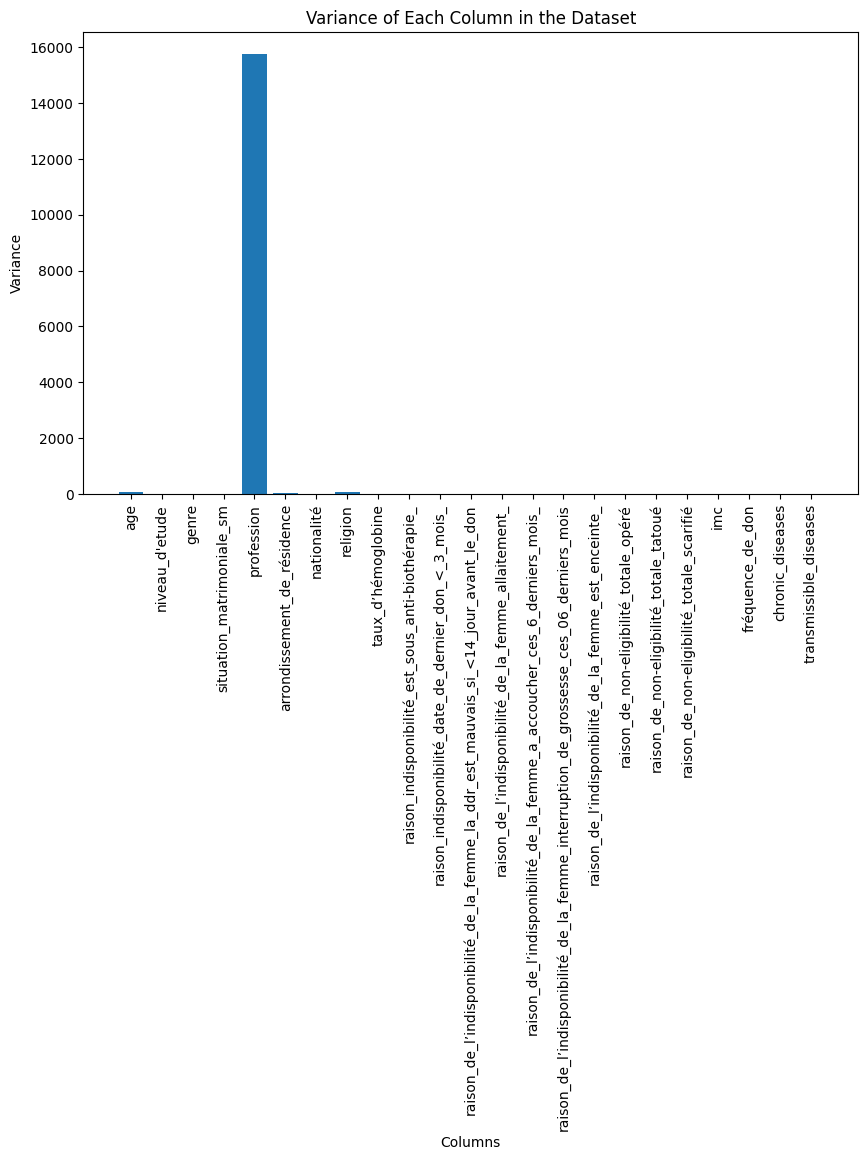

Variance of age: 78.81503521860787
Variance of niveau_d'etude: 1.3555126883879889
Variance of genre: 0.08891942440551164
Variance of situation_matrimoniale_sm: 0.7701785446890221
Variance of profession: 15751.460120615291
Variance of arrondissement_de_résidence: 19.45796668692581
Variance of nationalité: 0.7623218149841303
Variance of religion: 77.80743510468692
Variance of taux_d’hémoglobine: 12.917305968812666
Variance of raison_indisponibilité_est_sous_anti-biothérapie_: 0.0191316756071136
Variance of raison_indisponibilité_date_de_dernier_don_<_3_mois_: 0.0027026868318520665
Variance of raison_de_l’indisponibilité_de_la_femme_la_ddr_est_mauvais_si_<14_jour_avant_le_don: 0.0027026868318520665
Variance of raison_de_l’indisponibilité_de_la_femme_allaitement_: 0.0
Variance of raison_de_l’indisponibilité_de_la_femme_a_accoucher_ces_6_derniers_mois_: 0.0
Variance of raison_de_l’indisponibilité_de_la_femme_interruption_de_grossesse_ces_06_derniers_mois: 0.0
Variance of raison_de_l’indispo

In [198]:
# @title
from sklearn.preprocessing import LabelEncoder

sheet = sVoluntaire.sheet.copy()

sheet = sheet.drop(columns=excludes)


variance_results = calculate_variance(sheet)

# Plotting variance
plt.figure(figsize=(10, 6))
plt.bar(variance_results.keys(), variance_results.values())
plt.xticks(rotation=90)
plt.xlabel("Columns")
plt.ylabel("Variance")
plt.title("Variance of Each Column in the Dataset")
plt.tight_layout()
plt.show()

stage_1_validated = []
to_be_futher_checked = [ ]
for col, var in variance_results.items():
    if var > 0:
        stage_1_validated.append(col)
    else :
      excludes.append(col)
    if var > .7 and not pd.api.types.is_numeric_dtype(sVoluntaire.sheet[col]):
        to_be_futher_checked.append(col)
    print(f"Variance of {col}: {var}")


In [199]:
print ('Passed variance test = ' , len (stage_1_validated) * 100 / len ( sVoluntaire.get_columns()) , '%')
print ('To be further checked = ' , len (to_be_futher_checked) * 100 / len ( sVoluntaire.get_columns()) , '%')

Passed variance test =  45.23809523809524 %
To be further checked =  14.285714285714286 %




---


**Frequency plot to better understand the cause of the high variances in `to_be_checked`:**

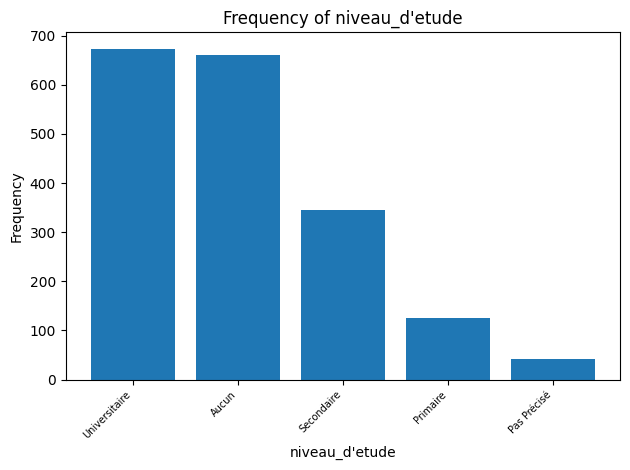

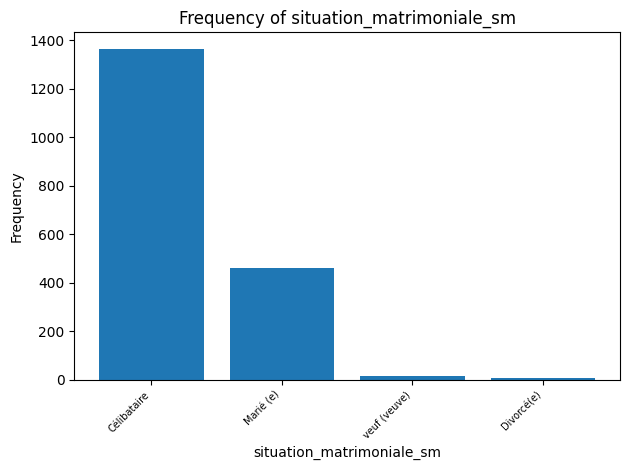

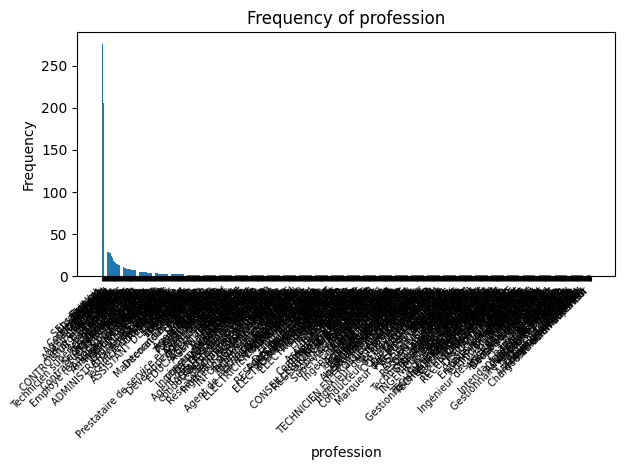

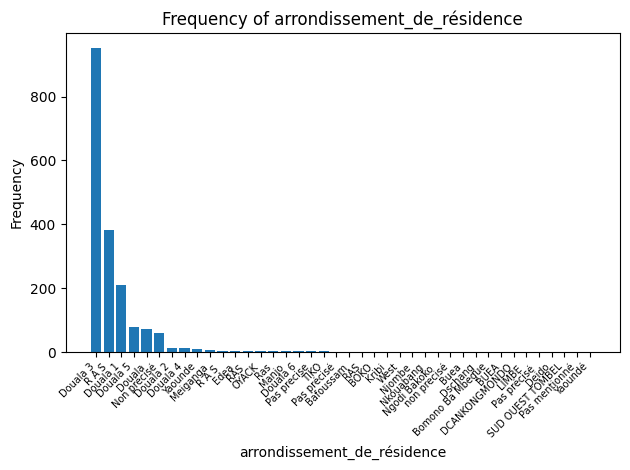

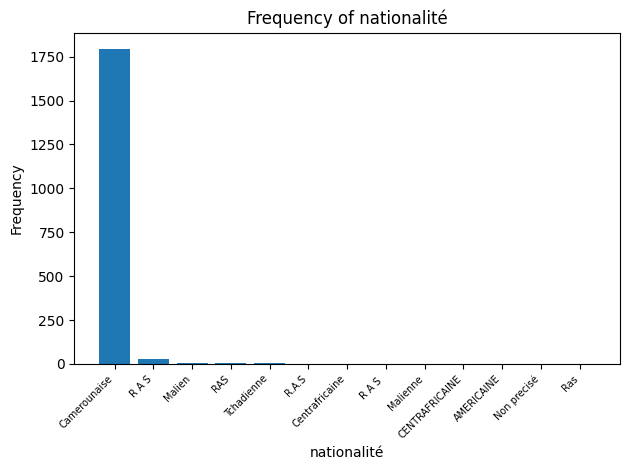

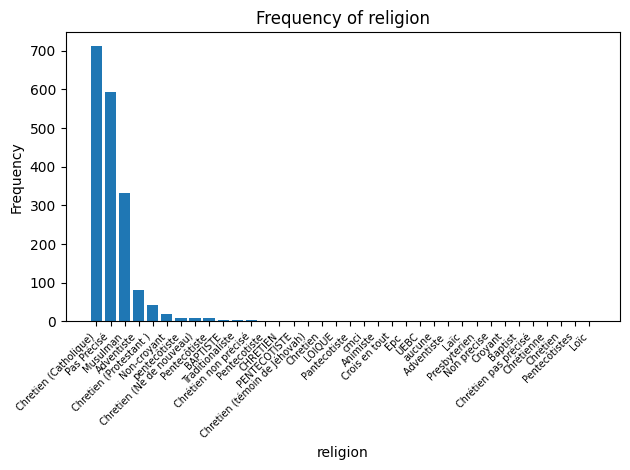

In [200]:
for col in to_be_futher_checked:
  sVoluntaire.plot_frequency(col)
  plt.show()



---


**applying preprocessing on non-numeric columns with high variance. This will group proffesions , and other categorical records with very high variance into general groups using well defined functions**




In [201]:
# @title
import re

sVoluntaire.pre_processing_functions = []  # Clear existing functions


#Functions

# Profession
def categorize_profession(profession):
    if not profession or profession in ['pas precise', 'pas précisé', 'pas mentionné', 'pas precisé', 'non precise', 'non precisé', 'ras', 'r a s', 'sp', 's1p']:
        return "autre"


    if re.search(r'[eé]tudiant|[ée]l[eè]ve|[eé]tudiante|stagiaire|stagiaitaire', profession):
        return "Étudiant"

    elif re.search(r'informaticien|d[eé]veloppeur|programmeur|analyste|data scientist|ingénieur logiciel|web developer|web designer|ui/ux designer|graphic designer|cyber security|it support|system administrator|network engineer|database administrator|software engineer|informatticien|informatien|infor\'aticien|ingenieur en informatique|réseaux et télécommunications|content manager', profession):
        return "Technologies de l'information"

    elif re.search(r'ingénieur|architecte|technicien|mécanicien|électricien|ingénieur civil|ingénieur génie civil|technicien supérieur|electronicien|électronicien|agent technique|chaudron(?:ier|nier)|machiniste|tolier|tôlier|soudeur|maintenancier|électro(?:\s|-)?m[ée]cani(?:cien|que)|genie civil|constructeur|carreleur|géometre|ingenieur agronome|ingenieur en bateau|mecatronicien|maintenance industrielle|grutier|plantelier|rebobineur|cableur|operateur portique|électricité|trieur|vitri(?:er|é)|étanchéiste|ferrailleur|trefilleur|superviseur maintenance|collaborateur architecture|énergéticien|echaffaudeur', profession):
        return "Ingénierie et Technique"

    elif re.search(r'médecin|infirmier|pharmacien|dentiste|vétérinaire|kinésithérapeute|psychologue|aide-soignant|sage-femme|biologiste|chercheur|medecin|infirmièr|personnel de sante|laborantin|ambulancier|delegue medical|chimiste|auxiliaire de pharmacie|agent d\'appui pharmicie|ide urgentiste|brancardier|veterinaire|public health expert|administrateur des hopitaux|aide chirugien', profession):
        return "Santé et Médecine"

    elif re.search(r'enseignant|professeur|instituteur|éducateur|formateur|bibliothécaire|chercheur|maitresse|educateur des enfants|moniteur|pleg|philosophe', profession):
        return "Professeur"

    elif re.search(r'commercial|vend(?:eur|euse)|marketing|gest(?:ionnaire|ion)|compt(?:able|abilité)|financ(?:ier|e)|banqu(?:ier|e)|assur(?:eur|ance)|agent commercial|représentant|conseiller financier|consultant|business analyst|sales manager|account manager|marketing manager|project manager|product manager|customer service|human resources|businessm[ae]n|commerçant|entrepreneur|trader|homme d\'affaire|caissière|conseiller client|chargé de clientèle|agent de banque|auditeur interne|agent marketiste|conseiller juridique|fiscaliste|business development|market-developper|acheteur|responsable transport|agent immobilier|conseille agropastoral|chargée de communication|agent rh|assistant rh|agent de recouvriment|agent des ressourses humaines|manager administratif|directeur|directrice|contoleur gestion|jeune cadre|courtier|receptioniste', profession):
        return "Commerce et Gestion"

    elif re.search(r'artiste|musicien|acteur|écrivain|journaliste|photographe|designer|graphiste|styliste|danseur|chanteur|peintre|sculpteur|réalisateur|realisateur|infographe|beat maker|communicateur|decorateur|agent video|regisseur son et lumiere|serigraphe|sérigraph(?:e|ie)', profession):
        return "Arts et Culture"

    elif re.search(r'artisan|coiff(?:eur|euse)|couturi(?:er|ère)|cuisinier|pâtissier|patissier|boulanger|menuisier|m[ae]con|plombier|électricien|mécanicien|chauffeur|conducteur|agriculteur|pêcheur|éleveur|tailleur|menusier|ménuisier|mnuisier|planteur|cultivateur|cultuvateur|forestier|pecheur|estheti(?:cien|que)|soudeur|bijoutier|imprimeur|ouvrier|manoeuvre|manœuvre|maitre pecheur|staffeur|tapissier|ebeniste|cordonnier|coifffeur|restaurateur|brasseur|docker|do[lk]ker|pousseur|débrouillard|debrouillard|homme a tout faire|hoteli(?:er|ère|ere)|hotelluere|gouvernant d\'hotel|maître de chien', profession):
        return "Artisanat et Métiers Manuels"

    elif re.search(r'polic(?:ier|e)|militaire|pompier|agent de s[eé]curit[eé]|garde du corps|secouriste|douanier|gendarme|juge|avocat|huissier|vigil|controleur des douanes|security officer|juriste|agent hse|chef de sécurité|greffier|charger de la sécurité|securite', profession):
        return "Sécurité et Justice"

    elif re.search(r'sans emploi|chômeur|chomeur|au foyer|retraité|étudiant|femme au foyer|homme au foyer|ménagère|menagere', profession):
        return "Sans Emploi"

    elif re.search(r'administ(?:rateur|ration|ratif)|secretary|secretaire|secrétaire|clerical|office|assistant|assistante|archiviste|documentaliste|agent de liaison|transita(?:ire|ir)|déclarant|declarant|agent maritime|agent portuaire|agent communal|agent municipal|intendant|fonctionnaire|contractuel|cadre|logisticien', profession):
        return "Administration et Services"

    elif re.search(r'transport(?:eur)?|taxi(?:man)?|moto(?:\s|-)?taxi(?:man)?|chauffeur|conducteur|motoman', profession):
        return "Transport"

    elif re.search(r'pasteur|evangeliste|missionary|missionnaire', profession):
        return "Religieux"

    elif re.search(r'sportifs|footballeur|coach', profession):
        return "Sport"

    else:
        return 'autre'

#Locality
def map_locality_to_region(text):
    """
    Maps Cameroonian localities to official regions with enhanced coverage
    """

    region_map = {
        # Littoral Region
        'douala': 'Littoral',
        'deido': 'Littoral',
        'njombe': 'Littoral',
        'wouri': 'Littoral',
        'edea': 'Littoral',
        'ngodibakoko': 'Littoral',
        'boko': 'Littoral',
        'ngodi bakoko' : 'Littoral',
        'bomono ba mbegue' : 'Littoral',
        'douala ' : 'Littoral',

        # Centre Region
        'yaounde': 'Centre',
        'yaoundé' : 'Centre',
        'oyack': 'Centre',
        'mfoundi': 'Centre',
        'nkongsamba': 'Centre',
        'nkouabang': 'Centre',

        # West Region
        'bafoussam': 'Ouest',
        'dschang': 'Ouest',
        'manjo': 'Ouest',
        'bomonobambegue': 'Ouest',

        # Southwest Region
        'buea': 'Sud-Ouest',
        'limbe': 'Sud-Ouest',
        'tiko': 'Sud-Ouest',
        'sudouest': 'Sud-Ouest',

        # Adamawa Region
        'meiganga': 'Adamaoua',

        # South Region
        'kribi': 'Sud',

        # Special cases
        'ras': 'Autre',
        'r a s': 'Autre',
        'nonprecise': 'Autre',
        'pasprecise': 'Autre',
        'pasmentionne': 'Autre',
    }

    # Direct mapping check
    if text in region_map:
        return region_map[text]

    # Pattern-based matching
    patterns = {
        r'ouest$': 'Ouest',
        r'est$': 'Est',
        r'nord': 'Nord',
        r'sud(?!ouest)': 'Sud',
        r'centre': 'Centre',
        r'adamaoua': 'Adamaoua',
        r'pas ' : 'Autre',
        r'non ': 'Autre'
    }

    for pattern, region in patterns.items():
        if re.search(pattern, text):
            return region

    return 'Autre' # Rest

#Religion
def process_religion(text):
    text = text.lower()
    if re.search(r'chr[ée]tien.*|p[ea]ntec[oô]tiste.*|baptiste.*|adventiste.*|presbyterien.*|epc.*|croyant|uebc.*|cmci.*|baptist.*', text):
        return 'chrétien'
    elif text == 'musulman':
        return 'musulman'
    elif text == 'traditionaliste':
        return 'traditionaliste'
    elif text == 'animiste':
        return 'animiste'
    else:
        return 'autre'

#Nationality
def process_nationality(text):
    text = text.lower().strip()  # Lowercase and remove leading/trailing spaces
    if text in ['camerounaise', 'camerounais']:
        return 'camerounaise'
    elif text in ['malien', 'malienne']:
        return 'malienne'
    elif text in ['tchadienne', 'tchadien']:
        return 'tchadienne'

    elif text.replace (' ' , '') in ['ras' , 'r.a.s']:  # Match variations of 'RAS'
        return 'r a s' #frequency distribution shows this is more likely how it is named
    elif 'non p' in text: # for non-precise
        return 'autre'  # Keep original value if no match
    else : return text



religious = [
    lambda x: x.preprocess_columns(columns=['religion'], process_function=process_religion),
    ]

profession = [
    lambda x: x.preprocess_columns(columns=['profession'], process_function= categorize_profession)
]

locality = [
    lambda x: x.preprocess_columns(columns=['arrondissement_de_résidence'], process_function=lambda x: re.sub(r'\d+', '', x).replace('bonaberi', 'douala')),
    lambda x: x.preprocess_columns(columns=['arrondissement_de_résidence'], process_function=map_locality_to_region)
]

nationality = [
    lambda x: x.preprocess_columns(columns=['nationalité'], process_function=process_nationality)
]

functions = [
     lambda x: x.preprocess_columns(process_function=lambda x: x.lower().strip() if isinstance(x, str) else x), # Lowercase and strip profession first
    *religious, # Keep religious functions - they act on 'religion' column
    *profession,
    *locality,
     *nationality,
     lambda x: x.preprocess_columns(process_function=lambda x: x.lower().strip() if isinstance(x, str) else x),
]

sVoluntaire.add_pre_processing_function(functions) # Add the functions
sVoluntaire.apply_pre_processing_functions() # Apply them

**After applying preprocessing, check each columns that was to be futher checked descriptions**




In [202]:
#See length of unique values in to_be_futher_checked
for col in to_be_futher_checked:
  print(col , len(sVoluntaire.get_group(col)))

niveau_d'etude 5
situation_matrimoniale_sm 4
profession 15
arrondissement_de_résidence 8
nationalité 7
religion 5


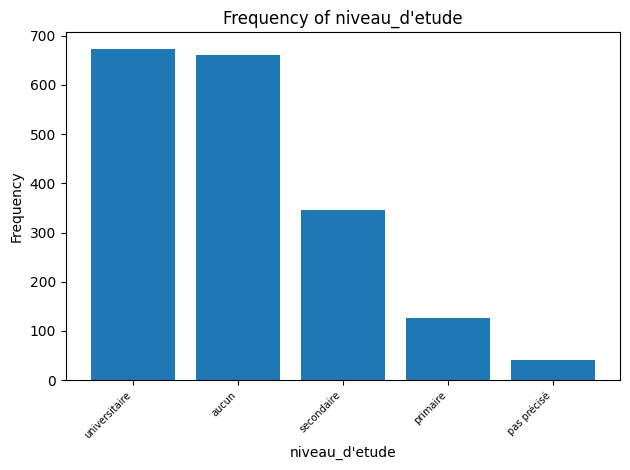

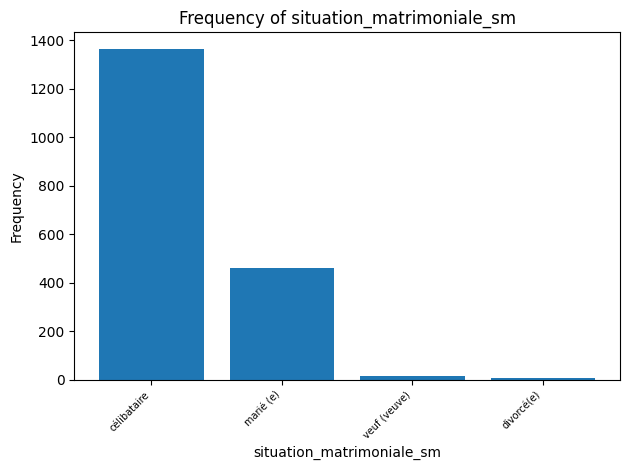

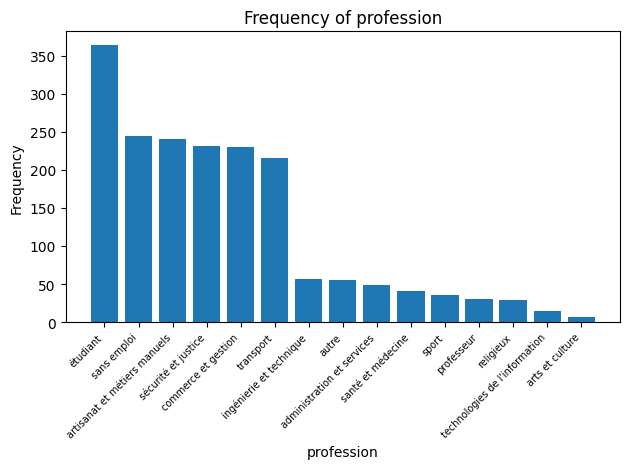

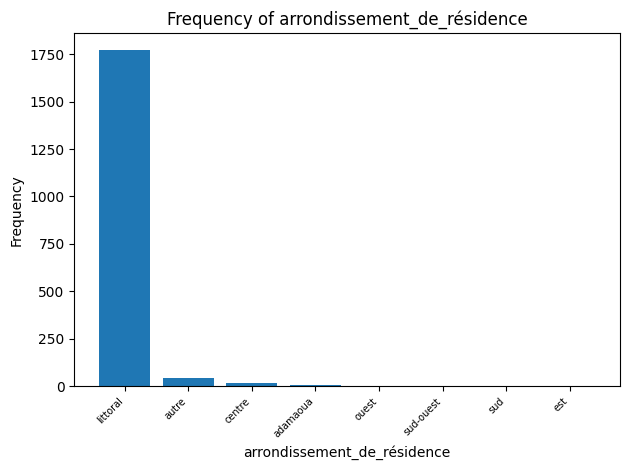

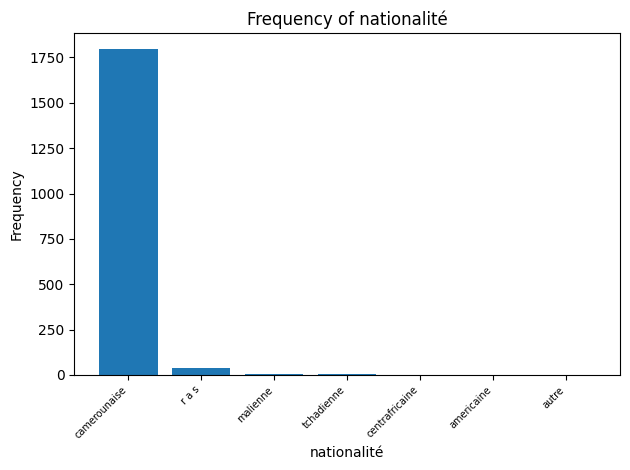

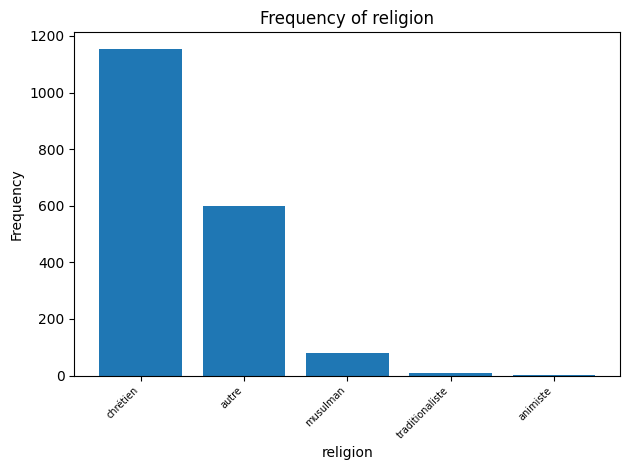

In [203]:
for col in to_be_futher_checked:
  sVoluntaire.plot_frequency(col)
  plt.show()

looking at `nationalité`, the most part-takers here are from cameroon which means it is inbalance, so we will use `arrondissement_de_résidence` for clustering 

In [204]:
excludes.append ( 'nationalité')



---
**Another processing to group unique records groups with only one participant to a new group called  `autre`**

*| "reason beign that, they have no relationship with
 the target prediction since they are constant with respect to it" |*




In [205]:
to_be_futher_checked

["niveau_d'etude",
 'situation_matrimoniale_sm',
 'profession',
 'arrondissement_de_résidence',
 'nationalité',
 'religion']



---


**Groups under columns in `to_be_futher_processed` for which the edligibility status doesn't change (`variance = 0`) within it is clustered to a new group called `autre` in this section.**

**Why?** *| "If there is a group where it's members have a constant edligibility status , then nothing about that group can give informative insights on edligibility but rather clustering those groups  into a new group can create some `within group variance`  which is good for training" |*




In [206]:
# @title


def variance_within_groups(self, target_column, other_columns, threshold=0, show_plot=False):
    """
    Calculates the variance of the target variable within groups of other columns.

    Returns:
        A dictionary where keys are column names and values are lists of excluded record names
        for columns whose variance did not meet the threshold.
    """
    excluded_records = {}
    df = self.sheet.copy()

    for col in other_columns:
        if col not in df.columns:
            print(f"Warning: Column '{col}' not found in DataFrame.")
            continue

        excluded_in_col = []
        for val in df[col].unique():
            subset = df[df[col] == val]
            if len(subset) == 0:
                continue

            # Handle cases where target_column is non-numeric (e.g. string labels)
            if not pd.api.types.is_numeric_dtype(subset[target_column]):
                le = LabelEncoder()
                subset[target_column] = le.fit_transform(subset[target_column].astype(str))

            variance = subset[target_column].var()

            if variance <= threshold or str (variance) == "nan":
                excluded_in_col.extend(subset[col].drop_duplicates().tolist())  # Store record names

            if show_plot:
                plt.figure()
                sns.histplot(subset[target_column], kde=True)
                plt.title(f"Distribution of {target_column} for {col} = {val} (Variance: {variance:.2f})")
                plt.show()

        if excluded_in_col:
            excluded_records[col] = excluded_in_col

    return excluded_records

In [207]:
#sited groups is a dictionary of those groups and respective parent columns
sited_groups = variance_within_groups(sVoluntaire , name , to_be_futher_checked, show_plot=False )

In [208]:
sited_groups

{'situation_matrimoniale_sm': ['veuf (veuve)'],
 'arrondissement_de_résidence': ['centre', 'adamaoua', 'ouest', 'est'],
 'nationalité': ['r a s', 'malienne', 'tchadienne', 'americaine', 'autre'],
 'religion': ['animiste']}

In [209]:
#this replaces this values with `autre` for the specified columns
sVoluntaire.add_pre_processing_function([replace_with_autre_preprocessor(sVoluntaire, sited_groups)])
sVoluntaire.apply_pre_processing_functions()



---

**Frequency plot to check processed columns and ensure all unique groups with one participant is merged to a new group >> `autre`**




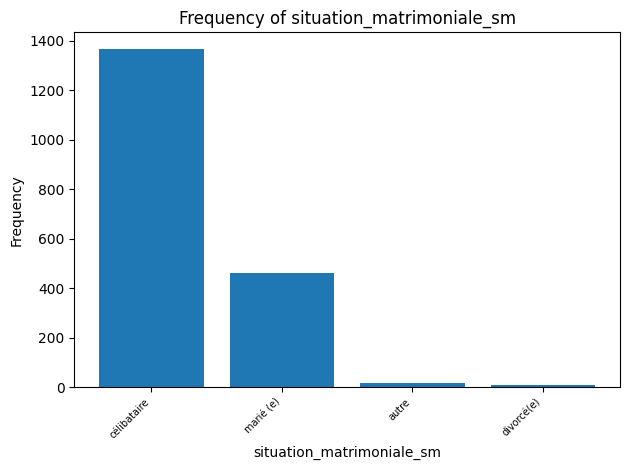

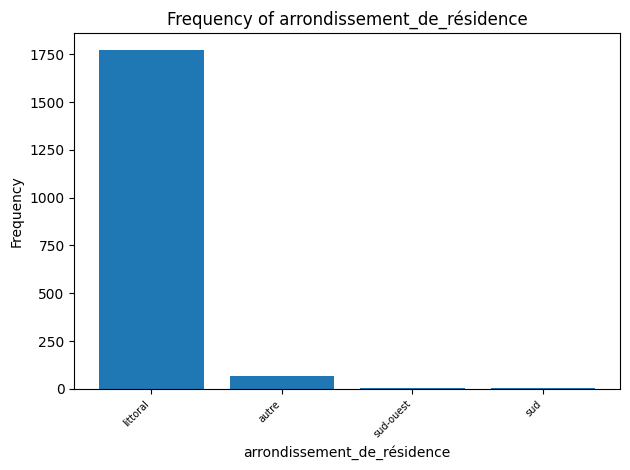

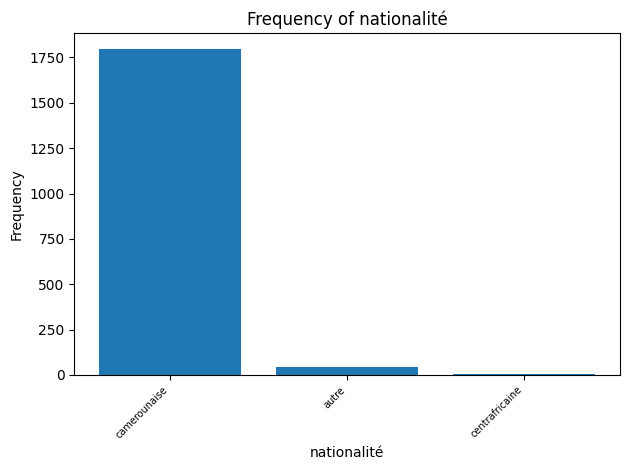

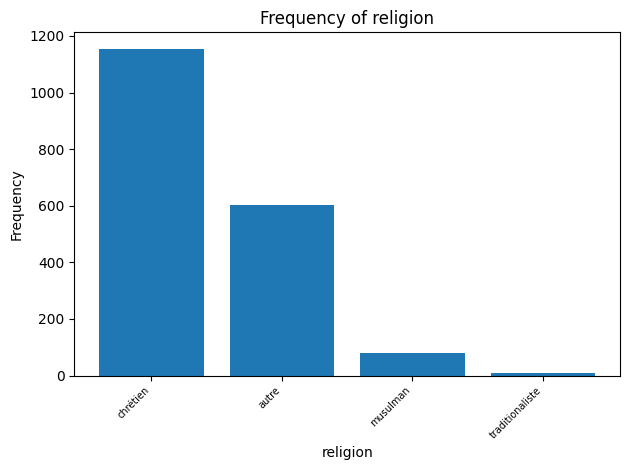

In [210]:
for col in sited_groups.keys():
  sVoluntaire.plot_frequency(col)
  plt.show()

---
**Detail analises on how strong the relationship between the  `non-excluded columns` and the target are, using `f-statitic` and `correlation`**

In [211]:
columns = [col for col in sVoluntaire.get_columns() if col not in excludes]
numeric_results_anova, categorical_results_anova , to_be_removed = calculate_dependence_on_target(
    sVoluntaire,
    target_column=name,
    other_columns=columns,
    test_type='anova', # Explicitly set to ANOVA, though it's the default
    show_plot=False
)

print("--- Results using ANOVA ---")
print("Numeric Dependence on Target:")
print(numeric_results_anova)
print("\nCategorical Dependence on Target:")
print(categorical_results_anova)



--- Results using ANOVA ---
Numeric Dependence on Target:
               Column  Correlation
0                 age     0.033428
1  taux_d’hémoglobine     0.108543
2                 imc    -0.040308
3    fréquence_de_don     0.107971

Categorical Dependence on Target:
                                               Column  ANOVA F-statistic  \
0                                      niveau_d'etude           0.631215   
1                                               genre         133.363025   
2                           situation_matrimoniale_sm           0.526598   
3                                          profession           2.377304   
4                         arrondissement_de_résidence           3.982697   
5                                            religion           1.621181   
6   raison_indisponibilité_est_sous_anti-biothérapie_         236.379606   
7   raison_indisponibilité_date_de_dernier_don_<_3...          29.061073   
8   raison_de_l’indisponibilité_de_la_femme_la_d


> **Short Analysis of Eligibility Status Predictors based on p-values from the above table**

**Significant Predictors:**

*   **Strongest impact:** Reasons for unavailability related to **low hemoglobin**, being **under antibiotics**, and **hemoglobin level category** .  Also significant are **nationality** and having been **operated on**.
*   **Medium impact:** **Gender**, **history of transfusion**, being **tattooed/scarified**, and having a **cardiac condition** significantly influence eligibility.
*   **Weaker, but significant impact:** Factors like transmissible_diseases , reasons related to **women's health (DDR)** and  **recent donation**, **recent STI** are statistically significant, but have a less pronounced effect.

**Non-Significant Predictors:**

*   **Education level, marital status and  religion** were found to be *not* statistically significant in predicting eligibility status in this analysis.



**In essence:** Health-related reasons for unavailability and certain demographic/medical history factors are key predictors of eligibility. Social factors like education and marital status appear to have no significant influence.




---


Creating validated list made up of atributes not excluded

In [212]:
to_be_removed

["niveau_d'etude",
 'situation_matrimoniale_sm',
 'arrondissement_de_résidence',
 'religion']

In [213]:
excludes.extend(to_be_removed) # Removing all columns which failed p-test

In [214]:
validated = [col for col in sVoluntaire.get_columns() if col not in excludes]
validated

['age',
 'genre',
 'profession',
 'taux_d’hémoglobine',
 'raison_indisponibilité_est_sous_anti-biothérapie_',
 'raison_indisponibilité_date_de_dernier_don_<_3_mois_',
 'raison_de_l’indisponibilité_de_la_femme_la_ddr_est_mauvais_si_<14_jour_avant_le_don',
 'raison_de_non-eligibilité_totale_opéré',
 'raison_de_non-eligibilité_totale_tatoué',
 'raison_de_non-eligibilité_totale_scarifié',
 'imc',
 'fréquence_de_don',
 'chronic_diseases',
 'transmissible_diseases']

# Clustering



---

Getting optimal k and vissualising clusters

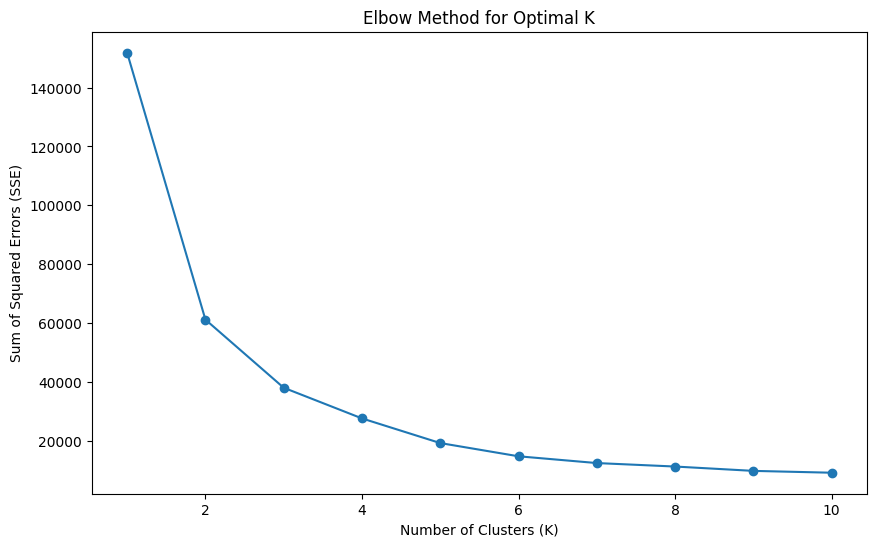

In [173]:
sVoluntaire.determine_optimal_k( validated)

In [178]:
K = 4

In [179]:
model = sVoluntaire.perform_kmeans_clustering(K , validated , show_plot=True)

c:\Users\Fru Gabriel\Desktop\pythonapps\AI_projects\hello\Petra\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning:

X does not have valid feature names, but PCA was fitted with feature names



save model

In [180]:
joblib.dump(model, os.path.join(parent_dir , 'models' ,'kmeans_model.joblib')) 

['c:\\Users\\Fru Gabriel\\Desktop\\pythonapps\\AI_projects\\hello\\Petra\\blood_donation_campaign_dashboard\\models\\kmeans_model.joblib']



# Mining Informatiion from clusters to get ideal donor cluster (group)




---
getting ideal donor based on how much of the datasets donors is covered


contains: 
2    36.46
1    29.04
0    19.61
Name: count, dtype: float64


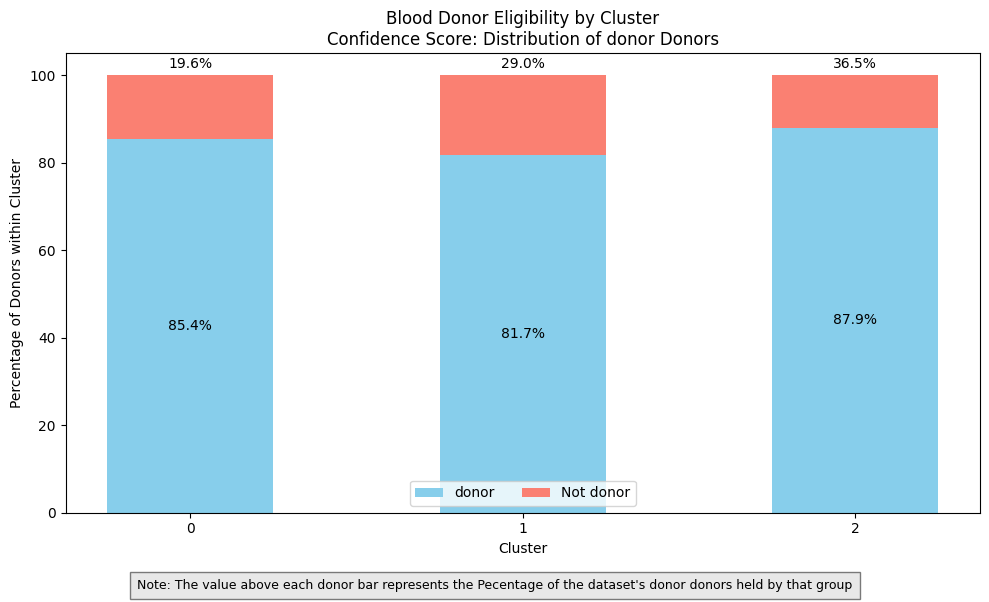

In [181]:
# @title
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

status = sVoluntaire.get_column(name)
clus = sVoluntaire.get_column('cluster')

clus_counts = pd.Series(clus).value_counts()

# Filter clusters for donor status (status == 1)
kl = clus[status == 1]
kl_counts = pd.Series(kl).value_counts()

# Calculate donor and not_donor percentages (for bar heights)
donor = kl_counts * 100 / clus_counts
not_donor = 100 - donor

number_records_in_sheet = sVoluntaire.sheet.shape[0]

# Percentage of dataset
contains = kl_counts / number_records_in_sheet
contains = contains * 100

print("contains: ")
print(contains.round(2))

# Plotting - Stacked Bar Chart with contains Score Labels
fig, ax = plt.subplots(figsize=(10, 6))

# Define colors for donor and not donor
donor_color = 'skyblue'
not_donor_color = 'salmon'

sorted_indices = sorted(donor.index)  # Sort indices for consistent order
x_pos = np.arange(len(sorted_indices))
bar_width = 0.5

bars_donor = []
bars_not_donor = []

for i, cluster_val in enumerate(sorted_indices):
    v_val = donor.get(cluster_val, 0)
    nv_val = not_donor.get(cluster_val, 0)

    # Create bars and store them for later access
    bar1 = ax.bar(x_pos[i], v_val, bar_width,
                  label='donor' if i == 0 else None, color=donor_color)
    bar2 = ax.bar(x_pos[i], nv_val, bar_width, bottom=v_val,
                  label='Not donor' if i == 0 else None, color=not_donor_color)

    bars_donor.extend(bar1)
    bars_not_donor.extend(bar2)

    # Display donor percentage inside the donor bar
    ax.text(bar1[0].get_x() + bar1[0].get_width() / 2,  # X position (center of donor bar)
            v_val / 2,  # Y position (middle of donor bar)
            f'{v_val:.1f}%',  # donor percentage label
            ha='center', va='center', color='black', fontsize=10)  # Formatting

    # Display contains percentage above the donor bar (outside)
    ax.text(bar1[0].get_x() + bar1[0].get_width() / 2,  # X position (center of donor bar)
            100.9,  # Fixed Y position above the bar (adjust if needed)
            f'{contains.get(cluster_val, 0):.1f}%',  # Contains percentage label
            ha='center', va='bottom', color='black', fontsize=10)  # Formatting


# Set x-axis ticks and labels
ax.set_xticks(x_pos)
ax.set_xticklabels(sorted_indices)

# Add legend, labels, and title
ax.legend(loc='lower center', ncol=2)
ax.set_xlabel("Cluster")
ax.set_ylabel("Percentage of Donors within Cluster")
ax.set_title("Blood Donor Eligibility by Cluster\nConfidence Score: Distribution of donor Donors")

plt.figtext(0.5, 0.01, "Note: The value above each donor bar represents the Pecentage of the dataset's donor donors held by that group",
            ha="center", fontsize=9, bbox={"facecolor": "lightgrey", "alpha": 0.5, "pad": 5})

plt.tight_layout(rect=[0, 0.04, 1, 1])  # Adjust layout for better spacing
plt.show()

 **From above, the `ideal donors` are donors of group 1 which contains 36.5 % of the dataset's `validated donors` and 87.9% of its population `are donors`**

---
*| "Now we going to inspect the charecteristics of this group.*


# Studying the ideal group



---


**Working henceforth with just subset of the data under group 1 (`The ideal group`)**

In [191]:
group1Sheet = get_cluster_subset(sVoluntaire , 1)
percentage_occupied = group1Sheet.sheet.shape[0] * 100  / sVoluntaire.sheet.shape[0]
print (f"""
\t_______ Groupe 1 _________\n
*\toccupied > {percentage_occupied:.2f} %
*\tedligible donors > {.877 * percentage_occupied:.2f} %
""")



	_______ Groupe 2 _________

*	occupied > 41.50 %
*	edligible donors > 36.47 %





---

Factors to study: Here numerical columns like `age`, .... will be removed and their categorical form like `age group`, ... will be used

In [183]:
targets = (
    'age',
    'imc',
    'taux_d’hémoglobine',
)

replacers = [
    "groupe_d'âge",
    'catégorie_d\'imc',
    "catégorie_de_niveau_d'hémoglobine"
]

validated = list (set ( validated) - set(targets)) +  replacers

In [184]:
validated

['transmissible_diseases',
 'chronic_diseases',
 'raison_de_non-eligibilité_totale_tatoué',
 'genre',
 'profession',
 'raison_indisponibilité_date_de_dernier_don_<_3_mois_',
 'raison_de_l’indisponibilité_de_la_femme_la_ddr_est_mauvais_si_<14_jour_avant_le_don',
 'fréquence_de_don',
 'raison_de_non-eligibilité_totale_opéré',
 'raison_de_non-eligibilité_totale_scarifié',
 'raison_indisponibilité_est_sous_anti-biothérapie_',
 "groupe_d'âge",
 "catégorie_d'imc",
 "catégorie_de_niveau_d'hémoglobine"]

In [185]:
def get_most_eligible_category(sheet, target, attribute):
    """
    Finds the category with the most eligible individuals.
    
    """
    
    # Check if target column exists
    if target not in sheet.sheet.columns:
        raise ValueError(f"Target column '{target}' not found in the DataFrame.")
        
    eligible_counts = (
        sheet.sheet
        .groupby(attribute)[target]  
        .agg(lambda x: (x == 1).sum())           # Count eligible (1 = True)
        .reset_index(name='eligible_count')
    )

    # Find attribute with maximum eligible donors
    max_group = eligible_counts.loc[eligible_counts['eligible_count'].idxmax()]

    return max_group[attribute], max_group['eligible_count']


In [ ]:
print("_"*5, "Analyses of attributes in this group", "_"*5, "\n")
total_members = group1Sheet.sheet.shape[0]
total_eligible = group1Sheet.sheet[name][ group1Sheet.sheet[name] == 1].shape[0]
for col in validated:
    most_frequent = group1Sheet.get_most_frequent(col)
    most_frequent_count = (group1Sheet.sheet[col][group1Sheet.sheet[col] == most_frequent]).shape[0]
    most_eligible, most_eligible_count = get_most_eligible_category(group1Sheet, name, col)
    occupied = most_frequent_count * 100 / total_members
    
    if most_frequent == most_eligible:
        print(f"{F.RESET}{occupied:.2f}% of this group have {F.YELLOW}{col}{F.RESET} as {F.GREEN}{most_frequent}{F.RESET}, which is also the most common among eligible donors ({most_eligible_count*100/total_eligible:.2f}%).\n")
    else:
        print(f"{F.RESET}{occupied:.2f}% of this group have {F.YELLOW}{col}{F.RESET} as {F.GREEN}{most_frequent}{F.RESET}. Meanwhile, {most_eligible_count*100/total_eligible:.2f}% of eligible donors have {F.YELLOW}{col}{F.RESET} as {F.GREEN}{most_eligible}{F.RESET}.\n")


_____ Analyses of attributes in this group _____ 

99.87% of this group have transmissible_diseases as non, which is also the most common among eligible donors (100.00%).

99.48% of this group have chronic_diseases as non, which is also the most common among eligible donors (100.00%).

99.48% of this group have raison_de_non-eligibilité_totale_tatoué as non, which is also the most common among eligible donors (100.00%).

90.47% of this group have genre as homme, which is also the most common among eligible donors (94.50%).

15.80% of this group have profession as commerce et gestion. Meanwhile, 16.79% of eligible donors have profession as ingénierie et technique.

99.74% of this group have raison_indisponibilité_date_de_dernier_don_<_3_mois_ as non, which is also the most common among eligible donors (100.00%).

99.61% of this group have raison_de_l’indisponibilité_de_la_femme_la_ddr_est_mauvais_si_<14_jour_avant_le_don as non, which is also the most common among eligible donors (100.0



---

how each of the to be studied atributes varries with edligibility in the ideal group. Edligible is `1` and 0 otherwise, the dashed lines above each category represents the total amount of people under that category 

In [188]:

#visualize_attribute_impact(group1Sheet, name, validated)



# Detailed Analises Of The Ideal donor profile



* **Genre :** Males occupy a greater portion of the ideal donor group, with **90.47%** of this group being male. This trend is consistent among eligible donors, where males are more likely to be eligible to donate blood than females.

---

* **Profession :** The most common profession in this group is **commerce et gestion**, accounting for **15.80%** of the group. However, the profession with the highest percentage of eligible donors is **ingénierie et technique**, indicating that individuals from this field are more likely to meet eligibility criteria.

---

* **Age :** The ideal donor profile predominantly consists of individuals within the **26-35** age range, which accounts for **75.07%** of the group. This age category is also the most common among eligible donors, comprising **65.14%** of them. This suggests that the late twenties to mid-thirties is a prime age range for blood donation eligibility.

---

* **Health Status :** The group predominantly consists of individuals without transmissible diseases (**99.87%**), chronic diseases (**99.48%**), or other health issues like tattoos (**99.48%**) or scars (**99.35%**). These factors are also common among eligible donors, indicating that good health is a critical component of the ideal donor profile.

---

* **Donation Frequency :** A significant portion of the group (**54.05%**) has not donated blood before, which is also the most common scenario among eligible donors (**45.82%**). This suggests that first-time donors are prevalent in both the overall group and among those eligible to donate.

---

* **Body Mass Index (BMI) :** The majority of the group (**96.21%**) has a BMI categorized as overweight, which is also the most common category among eligible donors (**85.38%**). This indicates that individuals with a slightly higher BMI are more represented in both groups.

---

* **Hemoglobin Level :** Most individuals in the group (**92.56%**) have a normal hemoglobin level, which is consistent with the eligibility criteria (**85.51%**). This suggests that maintaining a healthy hemoglobin level is important for eligibility.

